In [105]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.metrics import accuracy_score

from sklearn.feature_extraction import DictVectorizer

from sklearn.linear_model import LogisticRegression


## Homework

> Note: sometimes your answer doesn't match one of the options exactly. 
> That's fine. 
> Select the option that's closest to your solution.


### Dataset

In this homework, we will use the Bank Marketing dataset. Download it from [here](https://archive.ics.uci.edu/static/public/222/bank+marketing.zip).

Or you can do it with `wget`:

```bash
wget https://archive.ics.uci.edu/static/public/222/bank+marketing.zip
```

We need to take `bank/bank-full.csv` file from the downloaded zip-file.  
In this dataset our desired target for classification task will be `y` variable - has the client subscribed a term deposit or not. 

In [3]:
!wget https://archive.ics.uci.edu/static/public/222/bank+marketing.zip

--2024-10-07 23:26:57--  https://archive.ics.uci.edu/static/public/222/bank+marketing.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank+marketing.zip’

bank+marketing.zip      [           <=>      ] 999.85K   398KB/s    in 2.5s    

2024-10-07 23:27:01 (398 KB/s) - ‘bank+marketing.zip’ saved [1023843]



In [4]:
!unzip bank+marketing.zip

Archive:  bank+marketing.zip
 extracting: bank.zip                
 extracting: bank-additional.zip     


In [5]:
!unzip bank.zip

Archive:  bank.zip
  inflating: bank-full.csv           
  inflating: bank-names.txt          
  inflating: bank.csv                


In [47]:
df = pd.read_csv('bank-full.csv', delimiter=';')

In [48]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [49]:
target = 'y'

For the rest of the homework, you'll need to use only these columns:

* `age`,
* `job`,
* `marital`,
* `education`,
* `balance`,
* `housing`,
* `contact`,
* `day`,
* `month`,
* `duration`,
* `campaign`,
* `pdays`,
* `previous`,
* `poutcome`,
* `y`

### Data preparation

* Select only the features from above.
* Check if the missing values are presented in the features.

In [50]:
features = ['age',
 'job',
 'marital',
 'education',
 'balance',
 'housing',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [51]:
df = df[features]

In [52]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
balance      0
housing      0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

no missing values

### Question 1

What is the most frequent observation (mode) for the column `education`?

- `unknown`
- `primary`
- `secondary`
- `tertiary`

In [53]:
df.education.value_counts().sort_values(ascending=False)

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [54]:
df.education.describe()

count         45211
unique            4
top       secondary
freq          23202
Name: education, dtype: object

In [55]:
df.education.mode()

0    secondary
Name: education, dtype: object

answer: secondary

### Question 2

Create the [correlation matrix](https://www.google.com/search?q=correlation+matrix) for the numerical features of your dataset. 
In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

- `age` and `balance`
- `day` and `campaign`
- `day` and `pdays`
- `pdays` and `previous`

In [56]:
df.dtypes

age           int64
job          object
marital      object
education    object
balance       int64
housing      object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [57]:
numerical = [c for c in df.columns if df[c].dtype != 'object']
numerical

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [95]:
df.dtypes

age           int64
job          object
marital      object
education    object
balance       int64
housing      object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y             int64
dtype: object

In [96]:
categorical

['job', 'marital', 'education', 'housing', 'contact', 'month', 'poutcome']

In [59]:
assert len(df.columns) == len(numerical) + len(categorical)

In [60]:
corr_matrix = df[numerical].corr()
corr_matrix

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


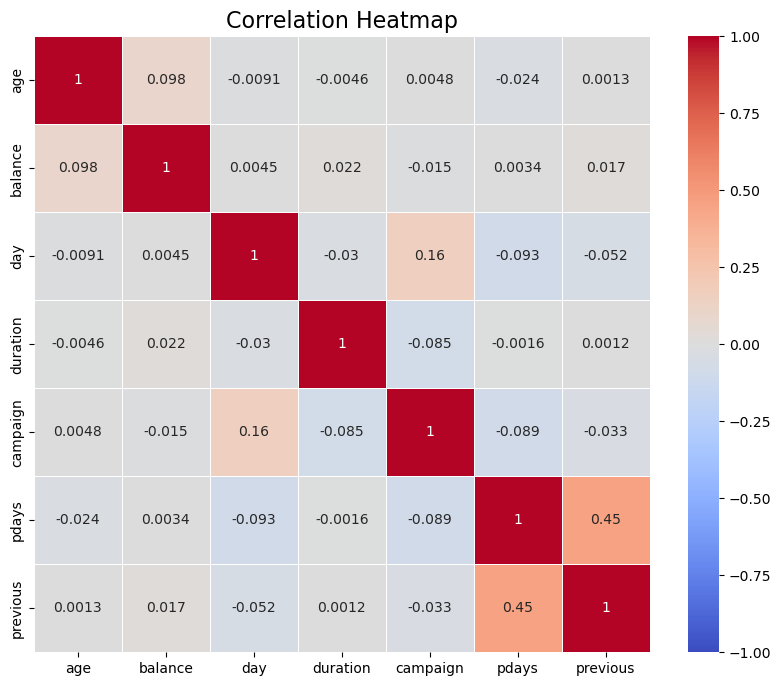

In [61]:
# Set up the figure size
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            linewidths=0.5, linecolor='white', square=True)

# Add a title
plt.title('Correlation Heatmap', fontsize=16)

# Show the plot
plt.show()

answer: pdays and previous

### Target encoding

* Now we want to encode the `y` variable.
* Let's replace the values `yes`/`no` with `1`/`0`.

### Split the data

* Split your data in train/val/test sets with 60%/20%/20% distribution.
* Use Scikit-Learn for that (the `train_test_split` function) and set the seed to `42`.
* Make sure that the target value `y` is not in your dataframe.

In [ ]:
{'yes': 1, 'no': 0}

In [62]:
one_zero = df['y'].map({'yes': 1, 'no': 0})

In [65]:
df['y'] = one_zero

In [66]:
df.head()

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,2143,yes,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,29,yes,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,2,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,1506,yes,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,1,no,unknown,5,may,198,1,-1,0,unknown,0


In [82]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

y_full_train = df_full_train['y'].values
y_train = df_train['y'].values
y_val = df_val['y'].values
y_test = df_test['y'].values


assert len(df_train) == len(y_train)
assert len(df_val) == len(y_val)
assert len(df_test) == len(y_test)
assert abs(len(df_val) - len(df_test)) <= 1

del df_full_train['y']
del df_train['y']
del df_val['y']
del df_test['y']

In [83]:
df_train.head()

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome
20326,32,technician,single,tertiary,1100,yes,cellular,11,aug,67,1,-1,0,unknown
24301,38,entrepreneur,married,secondary,0,yes,cellular,17,nov,258,1,-1,0,unknown
38618,49,blue-collar,married,secondary,3309,yes,cellular,15,may,349,2,-1,0,unknown
18909,37,housemaid,married,primary,2410,no,cellular,4,aug,315,1,-1,0,unknown
23081,31,self-employed,married,tertiary,3220,no,cellular,26,aug,74,4,-1,0,unknown


### Question 3

* Calculate the mutual information score between `y` and other categorical variables in the dataset. Use the training set only.
* Round the scores to 2 decimals using `round(score, 2)`.

Which of these variables has the biggest mutual information score?
  
- `contact`
- `education`
- `housing`
- `poutcome`

In [100]:
categorical = [c for c in df_train.columns if df_train[c].dtype == 'object']
categorical

['job', 'marital', 'education', 'housing', 'contact', 'month', 'poutcome']

In [102]:
mi_scores = []

for c in df_train[categorical].columns.to_list():
    # print(c)
    score = mutual_info_score(y_train, df_train[c])
    mi_scores.append((c, score))

cols = ['feature', 'mi_score']
mi_df = pd.DataFrame(mi_scores, columns=cols)
mi_df

,feature,mi_score
0,job,0.007316
1,marital,0.002050
2,education,0.002697
3,housing,0.010343
4,contact,0.013356
5,month,0.025090
6,poutcome,0.029533


In [103]:
mi_df.sort_values(by=['mi_score'], ascending=False)

,feature,mi_score
6,poutcome,0.029533
5,month,0.025090
4,contact,0.013356
3,housing,0.010343
0,job,0.007316
2,education,0.002697
1,marital,0.002050


In [ ]:
answer: poutcome

### Question 4

* Now let's train a logistic regression.
* Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
* Fit the model on the training dataset.
    - To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
    - `model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)`
* Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

What accuracy did you get?

- 0.6
- 0.7
- 0.8
- 0.9

In [106]:
dv = DictVectorizer(sparse=False)

In [109]:
train_dicts = df_train.to_dict(orient='records')
X_train  = dv.fit_transform(train_dicts)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

y_pred = model.predict(X_val)

acc = accuracy_score(y_val, y_pred)

print(f"Val_accuracy: {acc:0.2f}")

Val_accuracy: 0.90


answer: 0.9

### Question 5 

* Let's find the least useful feature using the *feature elimination* technique.
* Train a model with all these features (using the same parameters as in Q4).
* Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
* For each feature, calculate the difference between the original accuracy and the accuracy without the feature. 

Which of following feature has the smallest difference?

- `age`
- `balance`
- `marital`
- `previous`

> **Note**: The difference doesn't have to be positive.

In [129]:
acc

0.9007962840079629

In [144]:
def train_log_reg(df_train, df_val, y_train, y_val):
    acc_before  = 0.90079
    scores = []
    
    for f in df_train.columns:
        
        cols_used = [c for c in df_train.columns if c != f]

        dv = DictVectorizer(sparse=False)
        train_dicts = df_train[cols_used].to_dict(orient='records')
        X_train = dv.fit_transform(train_dicts)

        model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        val_dicts = df_val[cols_used].to_dict(orient='records')
        X_val = dv.transform(val_dicts)
        y_pred = model.predict(X_val)
        acc_score = accuracy_score(y_val, y_pred)
        abs_diff = abs(acc_before - acc_score)
        scores.append((f, acc_score, abs_diff))


    acc_before  = 0.9007
    cols = ['exluded_feature', 'val_accuracy', 'abs_diff']
    df_scores = pd.DataFrame(scores, columns=cols)

    return df_scores

        
        
    
    
    
    

In [146]:
df_exl_diff = train_log_reg(df_train, df_val, y_train, y_val)
df_exl_diff.sort_values(by='abs_diff', ascending=True)

,exluded_feature,val_accuracy,abs_diff
5,housing,0.900796,0.000006
10,campaign,0.900686,0.000104
3,education,0.901017,0.000227
11,pdays,0.901017,0.000227
6,contact,0.900464,0.000326
1,job,0.901128,0.000338
12,previous,0.901128,0.000338
0,age,0.901239,0.000449
7,day,0.901239,0.000449
2,marital,0.900133,0.000657


answer: accoring to my calculations the smallest difference was previous, but the idfferences were all pretty small, so its possible it was affected by rounding

### Question 6

* Now let's train a regularized logistic regression.
* Let's try the following values of the parameter `C`: `[0, 0.01, 0.1, 1, 10]`.
* Train models using all the features as in Q4.
* Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

Which of these `C` leads to the best accuracy on the validation set?

- 0.01
- 0.1
- 1
- 10
- 100

> **Note**: If there are multiple options, select the smallest `C`.

In [158]:
def log_reg_reg(df_train, df_val, y_train, y_val, C):
    dv = DictVectorizer(sparse=False)
    train_dicts = df_train.to_dict(orient='records')
    X_train  = dv.fit_transform(train_dicts)
    
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    val_dicts = df_val.to_dict(orient='records')
    X_val = dv.transform(val_dicts)
    
    y_pred = model.predict(X_val)
    
    acc = round(accuracy_score(y_val, y_pred), 3)
    
    print(f"C: {C} ----> val_accuracy: {acc}")

    return acc

In [159]:
scores = []
for C in [0.00001, 0.01, 0.1, 1, 10]:
    val_acc = log_reg_reg(df_train, df_val, y_train, y_val, C=C)
    scores.append((C, val_acc))

cols = ['C', 'val_accuracy']
df_reg_logreg = pd.DataFrame(scores, columns=cols)

df_reg_logreg.sort_values(by='val_accuracy', ascending=False)
    

C: 1e-05 ----> val_accuracy: 0.887
C: 0.01 ----> val_accuracy: 0.898
C: 0.1 ----> val_accuracy: 0.901
C: 1 ----> val_accuracy: 0.901
C: 10 ----> val_accuracy: 0.901


,C,val_accuracy
2,0.10000,0.901
3,1.00000,0.901
4,10.00000,0.901
1,0.01000,0.898
0,0.00001,0.887


answer: These best val_accuracy (with smallest C breaking ties) is 0.1